In [1]:
!pip install torch-geometric
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 60.8 MB/s eta 0:00:00


In [2]:
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, GINConv, GATConv, TransformerConv, global_mean_pool
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


In [3]:
print("Loading ESOL dataset...")
dataset = MoleculeNet(root="data/MoleculeNet", name="ESOL")
print(f"Dataset: {dataset}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of features: {dataset.num_node_features}")
print(f"Number of targets: {dataset.num_classes}")


Loading ESOL dataset...


Processing...


Dataset: ESOL(1128)
Number of graphs: 1128
Number of features: 9
Number of targets: 734


Done!
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/in_memory_dataset.py:91: UserWarning: Found floating-point labels while calling `dataset.num_classes`. Returning the number of unique elements. Please make sure that this is expected before proceeding.
  return self._infer_num_classes(self._data.y)


In [4]:
torch.manual_seed(42)
train_dataset = dataset[:int(len(dataset) * 0.8)]
val_dataset = dataset[int(len(dataset) * 0.8):int(len(dataset) * 0.9)]
test_dataset = dataset[int(len(dataset) * 0.9):]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nTrain size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")



Train size: 902
Val size: 113
Test size: 113


In [5]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GCN, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels))

        self.fc = Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index, batch):
        for conv, batch_norm in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index)
            x = batch_norm(x)
            x = F.relu(x)
            x = self.dropout(x)

        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x


In [6]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GraphSAGE, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels))

        self.fc = Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index, batch):
        for conv, batch_norm in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index)
            x = batch_norm(x)
            x = F.relu(x)
            x = self.dropout(x)

        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x

In [7]:
class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, dropout=0.5):
        super(GIN, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        self.convs.append(
            GINConv(
                torch.nn.Sequential(
                    Linear(in_channels, hidden_channels),
                    torch.nn.ReLU(),
                    Linear(hidden_channels, hidden_channels)
                )
            )
        )
        self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels))

        for _ in range(num_layers - 1):
            self.convs.append(
                GINConv(
                    torch.nn.Sequential(
                        Linear(hidden_channels, hidden_channels),
                        torch.nn.ReLU(),
                        Linear(hidden_channels, hidden_channels)
                    )
                )
            )
            self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels))

        self.fc = Linear(hidden_channels, out_channels)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index, batch):
        for conv, batch_norm in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index)
            x = batch_norm(x)
            x = F.relu(x)
            x = self.dropout(x)

        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x


In [8]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_heads=4, dropout=0.3):
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=num_heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * num_heads, hidden_channels, heads=num_heads, dropout=dropout)
        self.fc = Linear(hidden_channels * num_heads, out_channels)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        x = self.dropout(x)
        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x

In [9]:
class GraphTransformer(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_heads=4, num_layers=3, dropout=0.5):
        super(GraphTransformer, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.batch_norms = torch.nn.ModuleList()

        self.convs.append(TransformerConv(in_channels, hidden_channels, heads=num_heads, dropout=dropout))
        self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels * num_heads))

        for _ in range(num_layers - 1):
            self.convs.append(TransformerConv(hidden_channels * num_heads, hidden_channels, heads=num_heads, dropout=dropout))
            self.batch_norms.append(torch.nn.BatchNorm1d(hidden_channels * num_heads))

        self.fc = Linear(hidden_channels * num_heads, out_channels)
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index, batch):
        for conv, batch_norm in zip(self.convs, self.batch_norms):
            x = conv(x, edge_index)
            x = batch_norm(x)
            x = F.relu(x)
            x = self.dropout(x)

        x = global_mean_pool(x, batch)
        x = self.fc(x)
        return x


In [10]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        data.x = data.x.float()
        data.y = data.y.float().view(-1, 1)  # Reshape for regression

        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            data.x = data.x.float()
            data.y = data.y.float().view(-1, 1)

            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            total_loss += loss.item()

            y_true.append(data.y.cpu().numpy())
            y_pred.append(out.cpu().numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)

    # Compute regression metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return total_loss / len(loader), rmse, mae, r2


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}\n")

# Model configurations
models_config = {
    'GCN': GCN(dataset.num_node_features, 64, 1, num_layers=3, dropout=0.5),
    'GraphSAGE': GraphSAGE(dataset.num_node_features, 64, 1, num_layers=3, dropout=0.5),
    'GIN': GIN(dataset.num_node_features, 64, 1, num_layers=3, dropout=0.5),
    'GAT': GAT(dataset.num_node_features, 64, 1, num_heads=4, dropout=0.3),
    'GraphTransformer': GraphTransformer(dataset.num_node_features, 64, 1, num_heads=4, num_layers=3, dropout=0.5)
}



Using device: cuda



In [12]:
results = {}

for model_name, model in models_config.items():
    print(f"\n{'='*70}")
    print(f"Training {model_name}")
    print(f"{'='*70}")

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    best_val_rmse = float('inf')
    best_epoch = 0

    # Training loop
    for epoch in range(1, 101):
        train_loss = train(model, train_loader, optimizer, criterion, device)
        val_loss, val_rmse, val_mae, val_r2 = evaluate(model, val_loader, criterion, device)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch

        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}, Val R²: {val_r2:.4f}")

    # Test the model
    test_loss, test_rmse, test_mae, test_r2 = evaluate(model, test_loader, criterion, device)

    print(f"\nBest Validation RMSE: {best_val_rmse:.4f} at Epoch {best_epoch}")
    print(f"Test Results - RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, R²: {test_r2:.4f}")

    results[model_name] = {
        'val_rmse': best_val_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }



Training GCN
Epoch: 010, Train Loss: 2.1513, Val RMSE: 1.4928, Val MAE: 1.1592, Val R²: 0.4764
Epoch: 020, Train Loss: 1.7311, Val RMSE: 1.1189, Val MAE: 0.8665, Val R²: 0.7058
Epoch: 030, Train Loss: 1.6088, Val RMSE: 1.0518, Val MAE: 0.7966, Val R²: 0.7401
Epoch: 040, Train Loss: 1.6597, Val RMSE: 1.0753, Val MAE: 0.8241, Val R²: 0.7283
Epoch: 050, Train Loss: 1.3506, Val RMSE: 1.0111, Val MAE: 0.7519, Val R²: 0.7598
Epoch: 060, Train Loss: 1.2790, Val RMSE: 1.1791, Val MAE: 0.8956, Val R²: 0.6734
Epoch: 070, Train Loss: 1.3447, Val RMSE: 0.9837, Val MAE: 0.7397, Val R²: 0.7727
Epoch: 080, Train Loss: 1.2329, Val RMSE: 0.9532, Val MAE: 0.7278, Val R²: 0.7865
Epoch: 090, Train Loss: 1.4827, Val RMSE: 1.0800, Val MAE: 0.8312, Val R²: 0.7259
Epoch: 100, Train Loss: 1.2585, Val RMSE: 1.0198, Val MAE: 0.7670, Val R²: 0.7556

Best Validation RMSE: 0.9386 at Epoch 86
Test Results - RMSE: 1.0242, MAE: 0.8084, R²: 0.7328

Training GraphSAGE
Epoch: 010, Train Loss: 2.6241, Val RMSE: 1.5483, V

In [13]:
!pip install py3Dmol

In [14]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
import matplotlib.pyplot as plt
import py3Dmol

MOLECULAR VISUALIZATION - 2D

2D 구조 시각화:

분자 1:
  SMILES: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
  용해도 (log mol/L): -0.7700

분자 2:
  SMILES: CC12CCC3C(CCC4=CC(=O)CCC34C)C2CCC1C(=O)CO
  용해도 (log mol/L): -3.4500

분자 3:
  SMILES: Nc1ccc(cc1)S(=O)(=O)c2ccc(N)cc2
  용해도 (log mol/L): -3.0940


/tmp/ipython-input-4101044977.py:6: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  smiles_list = dataset.data.smiles
/tmp/ipython-input-4101044977.py:34: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4101044977.py:34: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4101044977.py:34: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) 

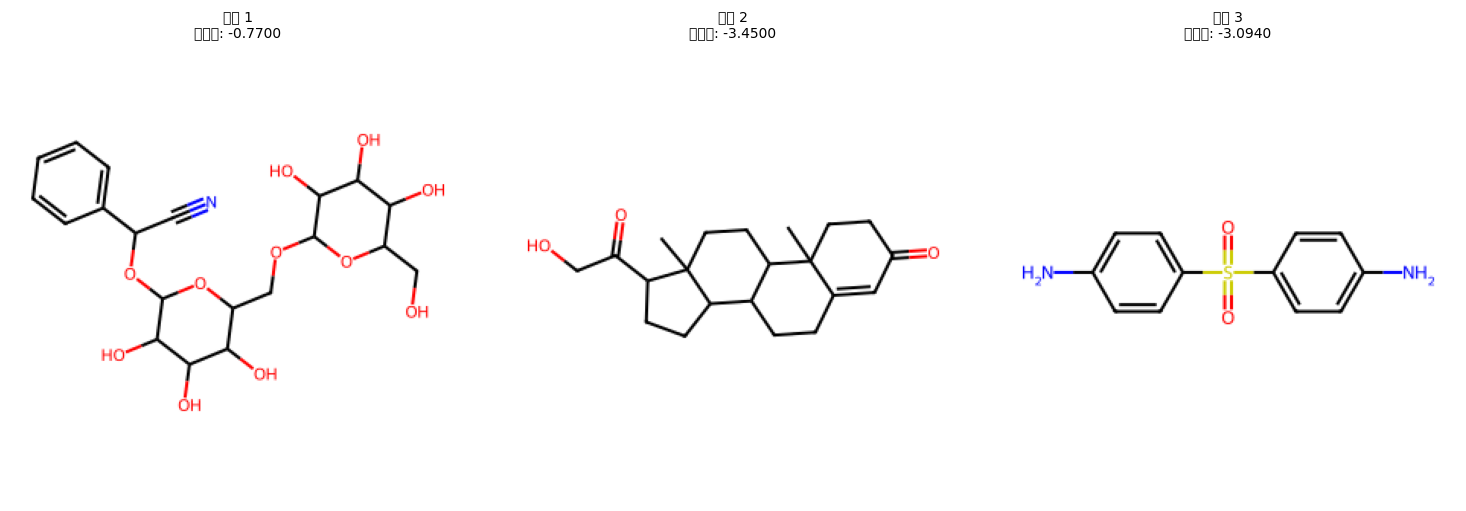

In [15]:
print("="*70)
print("MOLECULAR VISUALIZATION - 2D")
print("="*70)

# SMILES 추출
smiles_list = dataset.data.smiles

# 3개의 샘플 분자 시각화
num_samples = 3
fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))

print("\n2D 구조 시각화:")
for i in range(num_samples):
    example_index = i * 100  # 다른 분자들 샘플링
    smiles = smiles_list[example_index]
    target_value = dataset[example_index].y.item()

    print(f"\n분자 {i+1}:")
    print(f"  SMILES: {smiles}")
    print(f"  용해도 (log mol/L): {target_value:.4f}")

    # SMILES를 RDKit 분자로 변환
    mol = Chem.MolFromSmiles(smiles)

    # 2D 좌표 생성
    AllChem.Compute2DCoords(mol)

    # 2D 이미지 생성
    img = Draw.MolToImage(mol, size=(300, 300))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'분자 {i+1}\n용해도: {target_value:.4f}', fontsize=10)

plt.tight_layout()
plt.show()


In [16]:
print("\n" + "="*70)
print("MOLECULAR VISUALIZATION - 3D")
print("="*70)

example_index = 0
smiles = smiles_list[example_index]
print(f"\n3D 시각화 대상:")
print(f"  SMILES: {smiles}")
print(f"  용해도: {dataset[example_index].y.item():.4f}")

# SMILES를 RDKit 분자로 변환
mol = Chem.MolFromSmiles(smiles)

# 3D 좌표 생성
mol_3d = Chem.AddHs(mol)  # 수소 원자 추가
AllChem.EmbedMolecule(mol_3d, AllChem.ETKDG())  # 3D 형태 생성

# py3Dmol로 3D 시각화
block = Chem.MolToMolBlock(mol_3d)
view = py3Dmol.view(width=600, height=400)
view.addModel(block, "mol")
view.setStyle({"stick": {}})  # Stick 스타일
view.zoomTo()
print("\n3D 구조가 아래에 표시됩니다 (마우스로 회전 가능):")
view.show()



MOLECULAR VISUALIZATION - 3D

3D 시각화 대상:
  SMILES: OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
  용해도: -0.7700

3D 구조가 아래에 표시됩니다 (마우스로 회전 가능):


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


용해도 비교 - 최고 vs 최저

최저 용해도:
  SMILES: Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl 
  용해도: -11.6000

최고 용해도:
  SMILES: CC(=O)N
  용해도: 1.5800


/tmp/ipython-input-2397728265.py:32: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2397728265.py:32: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2397728265.py:32: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2397728265.py:32: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2397728265.py:32: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2397728265.py:32: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s)

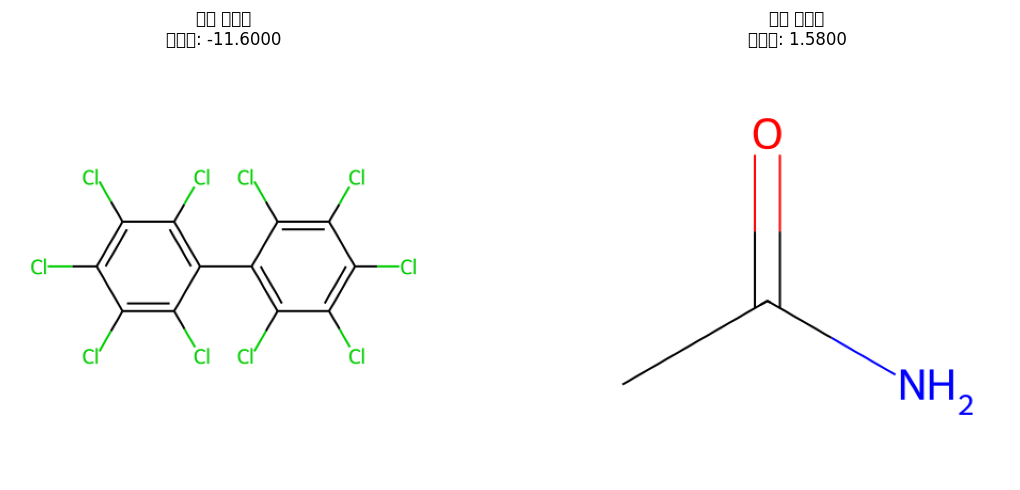


시각화 완료!


In [17]:
print("\n" + "="*70)
print("용해도 비교 - 최고 vs 최저")
print("="*70)

# 용해도 값으로 정렬
import numpy as np
solubility_values = [dataset[i].y.item() for i in range(len(dataset))]
sorted_indices = np.argsort(solubility_values)

# 가장 낮은 용해도와 가장 높은 용해도 분자
lowest_idx = sorted_indices[0]
highest_idx = sorted_indices[-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (data_idx, title) in enumerate([(lowest_idx, '최저 용해도'), (highest_idx, '최고 용해도')]):
    smiles = smiles_list[data_idx]
    sol_value = dataset[data_idx].y.item()

    print(f"\n{title}:")
    print(f"  SMILES: {smiles}")
    print(f"  용해도: {sol_value:.4f}")

    mol = Chem.MolFromSmiles(smiles)
    AllChem.Compute2DCoords(mol)
    img = Draw.MolToImage(mol, size=(400, 400))

    axes[idx].imshow(img)
    axes[idx].axis('off')
    axes[idx].set_title(f'{title}\n용해도: {sol_value:.4f}', fontsize=12)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("시각화 완료!")
print("="*70)